> ⚙️ **MODÜL: İnteraktif Personel Sorgulama**
> 
> Kullanıcıdan alınan **ID numarasına** göre ilgili personelin tüm *fotokopi, tarama ve yazdırma* işlem geçmişini kronolojik olarak ekrana yazdıran interaktif fonksiyon.
çalıştırmak için: personel_sorgulama_programi(df_temiz)

In [2]:
def personel_sorgulama_programi(df):
    print("="*60)
    print("--- PERSONEL İŞLEM SORGULAMA PROGRAMI ---")
    print("  (Programdan çıkmak için 'q' yazın)         ")
    print("="*60)
    
    while True:
        aranan_id = input("\n Personel ID numarası  ")
        
   
        if aranan_id.lower() == 'q':
            print("Program kapatılıyor... ")
            break
            
        # Girdiği ID'yi verideki ID formatıyla aynı yapıyoruz (string)
        aranan_id = str(aranan_id)
        
        # Veriyi sadece o kişiye göre filtrele
        personel_verisi = df[df['ID'] == aranan_id].copy()
        
        # Eğer bu ID sistemde yoksa uyarı ver ve başa dön
        if personel_verisi.empty:
            print(f"Sistemde '{aranan_id}' ID numaralı biri yok. ")
            continue
            
        
        # Tarihe göre sıralayıp, ekranda sadece işimize yarayan kolonları gösterelim
        gosterilecek_kolonlar = ['Tarih', 'genel_renkli', 'genel_sb', 'dijital_islemler', 'toplam']
        sonuc_tablosu = personel_verisi[gosterilecek_kolonlar].sort_values('Tarih')
        
        # 1. Günlük Dökümü Ekrana Bas
        print(f"\n--- ({aranan_id}) İçin Günlük İşlem Dökümü ---")
        print(sonuc_tablosu.to_string(index=False))
        
        # 2. En Alta Genel Toplam yazdır
        print("\n--- Tüm Zamanların (16 Aylık) Toplamı ---")
        toplamlar = sonuc_tablosu[['genel_renkli', 'genel_sb', 'dijital_islemler', 'toplam']].sum()
        print(toplamlar.to_frame(name='TOPLAM').T.to_string(index=False))
        print("-" * 60)

# Programı çalıştırmak için temiz veriyi fonksiyona ver:
# personel_sorgulama_programi(df)

In [3]:
personel_sorgulama_programi(df)

NameError: name 'df' is not defined

# 🖨️ Kurumsal Fotokopi ve Yazıcı Kullanım Analizi (16 Aylık Periyot)

Bu projenin amacı, 16 aylık kurumsal fotokopi, tarama ve faks loglarını bir araya getirerek şirket içi donanım kullanım trendlerini, operasyonel yoğunluk dönemlerini ve personel bazlı tüketim alışkanlıklarını istatistiksel olarak analiz etmektir. 


### 🛠️ Veri İşleme ve Hazırlık Boru Hattı (Data Pipeline)

Projeye başlarken günlük log dosyaları üzerinde sırasıyla şu işlemler gerçekleştirilmiştir:

*   **1. Veri Birleştirme:** 16 farklı CSV dosyası `glob` kütüphanesi ile tek seferde okunmuş ve dosya isimlerindeki tarih bilgileri ayrıştırılarak ana veriye yeni bir zaman boyutu olarak eklenmiştir.
*   **2. Veri Temizleme:** Sütun isimlerindeki Türkçe karakterler ve boşluklar Python standartlarına uygun hale getirilmiş, eksik veri (NaN) içeren hücreler sıfır (0) ile doldurulmuştur. Olası toplama hatalarını önlemek adına `ID` sütununun veri tipi `String` olarak sabitlenmiştir.
*   **3. Feature Engineering:** 
    *   **Metrik Sadeleştirme:** Tek taraflı, çift taraflı, kopya ve çıktı gibi karmaşık kırılımlar toparlanarak üç ana metrik oluşturulmuştur: `genel_renkli`, `genel_sb` (siyah-beyaz) ve `dijital_islemler` (tarama/faks).
    *   **Zaman Boyutlandırılması:** İleri düzey analizler ve filtrelemeler için `Tarih` sütunundan `Donem` (Yıl-Ay), `Yıl`, `Ay`, `Gün` ve `Haftanın_Günü` özellikleri türetilmiştir.
*   **4. Sütun Optimizasyonu:** Analitik değeri olmayan sistem sütunları atılmış ve tablo, tanımlayıcı bilgilerin solda, sayısal metriklerin sağda olduğu jilet gibi bir yapıya kavuşturulmuştur.

### 📊 Keşifçi Veri Analizi (EDA) ve Görselleştirme Çıktıları

Temizlenen veri seti üzerinden şirketin makro düzeydeki kullanım alışkanlıkları görselleştirilmiştir:

*   **Zaman Serisi Trendleri:** Aylık bazda tüketim çubuk grafikleriyle (Bar Plot) görselleştirilmiş, üzerine 3 aylık hareketli ortalama (Moving Average) çizgisi bindirilerek ana trend (artış/azalış) ortaya çıkarılmıştır.
*   **Referans Ölçütleri:** Aylık tüketim medyanı hesaplanarak grafiğe eşik çizgisi olarak eklenmiş, böylece ekstrem yoğunluk yaşanan aylar (işe alım dönemleri, yıl sonu kapanışları vb.) anında görünür kılınmıştır.

In [4]:
import pandas as pd
import glob
import os
import numpy as np

dosya_yollari = sorted(
    glob.glob(r"C:\Users\btstajyer\Desktop\yazici_kullanimi\reports\*.csv")
)

df_listesi = []

for dosya in dosya_yollari:

    with open(dosya, "r", encoding="utf-8-sig") as dosya_objesi:
        satirlar = dosya_objesi.readlines()

    baslik_satiri = next(
        i for i, satir in enumerate(satirlar)
        if "Etkin Alan" in satir and "Kullanıcı kimliği" in satir
    )

    temp_df = pd.read_csv(
        dosya,
        skiprows=baslik_satiri,
        encoding="utf-8-sig"
    )
    
    # Dosyanın adından tarihi çek
    # Örnek dosya yolu: 'veri_klasoru/2026-08-15.csv'
    # basename -> sadece '2026-08-15.csv' kısmını alır
    dosya_adi = os.path.basename(dosya)
    
    # '.csv' kısmını atıyoruz, geriye sadece tarih metni kalıyor
    tarih_metni = dosya_adi.replace(".csv", "")
    
    # Eğer dosya adında başka yazılar da varsa (örn: 'fotokopi_2026-08-15') 
    # tarih_metni = tarih_metni.split('_')[-1] gibi bir taktikle sadece tarihi koparabilirsin.
    
    # 4. Veri setine 'Tarih' adında yepyeni bir sütun ekle ve bu metni bas
    temp_df['Tarih'] = tarih_metni
    
    # Listeye ekle
    df_listesi.append(temp_df)

# 5. Tüm listeyi tek bir tabloda birleştir
df = pd.concat(df_listesi, ignore_index=True)

df['Tarih'] = pd.to_datetime(
    df['Tarih'].str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
    format='%Y-%m-%d'
)

# Veriyi zamana göre sıralayalım
df.sort_values('Tarih', inplace=True)
df.reset_index(drop=True, inplace=True)

c:\Users\btstajyer\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\btstajyer\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:

yeni_isimler = {
    'Etkin Alan': 'etkin_alan',
    'Kullanıcı kimliği': 'ID',
    'Tam ad': 'isim_soyisim',
    'YazdırRenk1 Taraflı': 'renkli_tek_sayfa',
    'YazdırRenk2 Taraflı': 'renkli_cift_sayfa',
    'YazdırSiyah Beyz1 Taraflı': 'sb_tek_sayfa',
    'YazdırSiyah Beyz2 Taraflı': 'sb_cift_sayfa',
    'KopyalaRenk1 Taraflı': 'kopya_renkli_tek',
    'KopyalaRenk2 Taraflı': 'kopya_renkli_cift',
    'KopyalaSiyah Beyz1 Taraflı': 'kopya_sb_tek',
    'KopyalaSiyah Beyz2 Taraflı': 'kopya_sb_cift',
    'Faks iletimi': 'faks_giden',
    'Tara': 'tarama',
    'Faks alma': 'faks_gelen',
    'Sayfa sayısıAlt toplam': 'toplam'
}

df.rename(columns=yeni_isimler, inplace=True)
print(df.columns.tolist())

['etkin_alan', 'ID', 'isim_soyisim', 'renkli_tek_sayfa', 'renkli_cift_sayfa', 'sb_tek_sayfa', 'sb_cift_sayfa', 'kopya_renkli_tek', 'kopya_renkli_cift', 'kopya_sb_tek', 'kopya_sb_cift', 'faks_giden', 'tarama', 'faks_gelen', 'toplam', 'Tarih']


In [6]:
df.to_excel(r"C:\Users\btstajyer\Desktop\yazici_kullanimi\veri.xlsx", index=False)
df.to_csv(r"C:\Users\btstajyer\Desktop\yazici_kullanimi\veri.csv", index=False, encoding="utf-8-sig")

In [7]:
df.drop(columns=['etkin_alan', 'isim_soyisim'], inplace=True)

In [8]:
df.drop(columns=["faks_gelen"], inplace=True)
df.drop(columns="faks_giden", inplace=True)

In [9]:
df[df["Tarih"]==pd.to_datetime("2025-02-24")]["toplam"].sum()

850

In [10]:
# 1. Şirket genelinde haftalık toplam trend 
sirket_haftalik = (
    df.groupby(pd.Grouper(key="Tarih", freq="W"))[
        ["toplam"]
    ]
    .sum()
)

aylik_veri = (
    df.groupby(pd.Grouper(key="Tarih", freq="ME"))[
        ["toplam"]
    ]
    .sum()
)

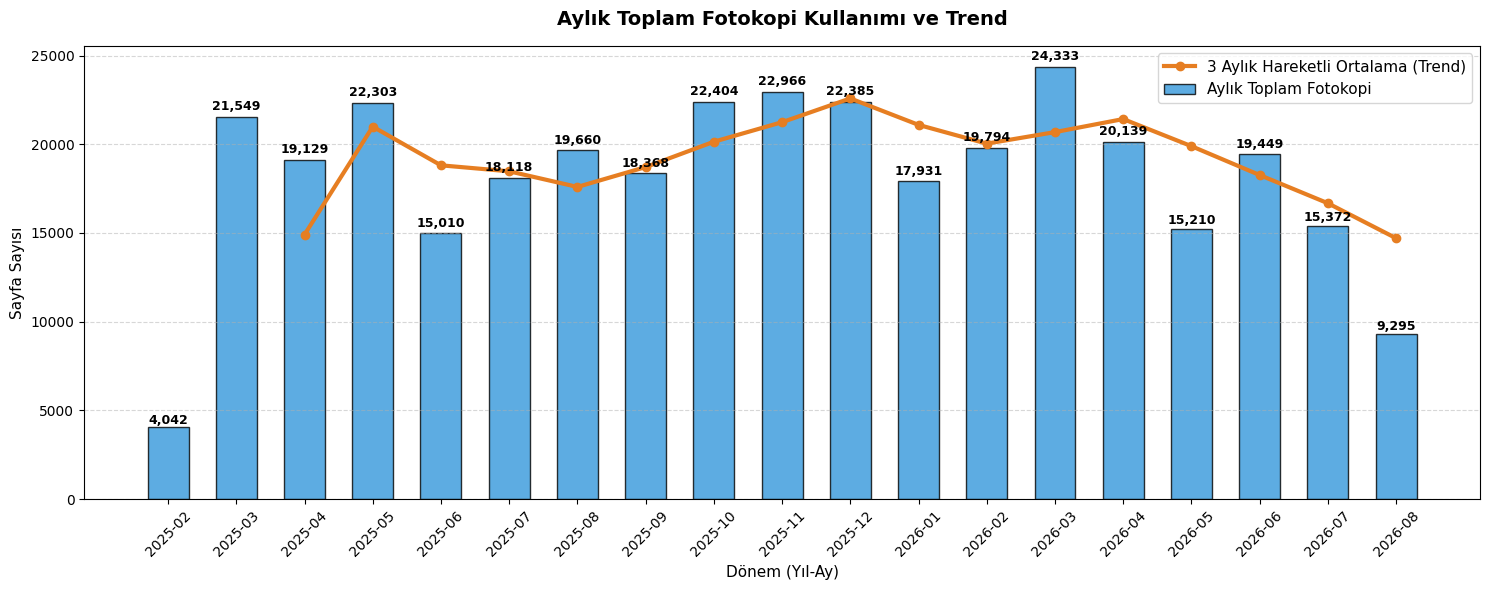

In [11]:
import matplotlib.pyplot as plt
# 1. 3 Aylık Hareketli Ortalamayı Hesapla
hareketli_ortalama = aylik_veri.rolling(window=3).mean()

# 2. X Eksenindeki Tarihleri String Formatına Çevir (Barların tam oturması için)
aylar_str = aylik_veri.index.strftime('%Y-%m')

# 3. Grafiği Oluştur
plt.figure(figsize=(15, 6))

# Aylık Toplamlar (Sütun Grafiği)
aylik_veri = aylik_veri.squeeze("columns")
hareketli_ortalama = hareketli_ortalama.squeeze("columns")

plt.bar(
    aylar_str,
    aylik_veri.values,
    color="#3498db",
    alpha=0.8,
    edgecolor="black",
    width=0.6,
    label="Aylık Toplam Fotokopi"
)

# 3 Aylık Hareketli Ortalama (Trend Çizgisi)
plt.plot(aylar_str, hareketli_ortalama.values, color='#e67e22', linewidth=3, marker='o', label='3 Aylık Hareketli Ortalama (Trend)')

# 4. Sütunların Üzerine Sayısal Değerleri Yazdırma (Data Labels)
for i, deger in enumerate(aylik_veri.values):
    plt.text(i, deger + (deger * 0.01), f'{int(deger):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Eksen ve Başlık Düzenlemeleri
plt.title("Aylık Toplam Fotokopi Kullanımı ve Trend", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Dönem (Yıl-Ay)", fontsize=11)
plt.ylabel("Sayfa Sayısı", fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

In [12]:
aylik_toplamlar = df.set_index('Tarih').resample('ME')['toplam'].sum()


In [13]:
print("--- AYLIK KULLANIM DAĞILIMI İSTATİSTİKLERİ ---")
print(f"Medyan Değer       : {aylik_medyan:,.0f} sayfa")
print(f"Aritmetik Ortalama : {aylik_toplamlar.mean():,.0f} sayfa")
print(f"Minimum Ay         : {aylik_toplamlar.min():,.0f} sayfa")
print(f"Maksimum Ay        : {aylik_toplamlar.max():,.0f} sayfa")

--- AYLIK KULLANIM DAĞILIMI İSTATİSTİKLERİ ---


NameError: name 'aylik_medyan' is not defined

--- AYLIK KULLANIM DAĞILIMI İSTATİSTİKLERİ ---

    Medyan Değer       : 19,660 sayfa
    Aritmetik Ortalama : 19,654 sayfa
    Minimum Ay         : 15,010 sayfa (2025 Haziran)
    Maksimum Ay        : 24,333 sayfa (2026 Mart)



Trend açısından 3 dönem görünüyor:
Mart-Eylül 2025 -> Dalgalı, ancak genel olarak 18-22 bin bandında.
Ekim-Aralık 2025 -> Güçlü dönem, üç ay da 22 binin üzerinde.
Ocak-Temmuz 2026 -> Mart aynıdaki zirve haricinde zayıflama. Hareketli ortalama düşüşte.
    

In [ ]:
subat25Data= df[(df["Tarih"].dt.year==2025 ) & (df["Tarih"].dt.month==2)]
agustos26Data= df[(df["Tarih"].dt.year==2026 ) & (df["Tarih"].dt.month==8)]
df.drop(subat25Data.index, inplace=True)
df.drop(agustos26Data.index, inplace=True)


In [ ]:
# 1. Tarih Sütunundan 'Yıl-Ay' Dönem Formatını Oluşturma
# (Tarih sütunu datetime formatında değilse önce pd.to_datetime ile çevrilmelidir)
df['Donem'] = df['Tarih'].dt.strftime('%Y-%m')

# 2. Pivot Tabloyu Oluşturma
personel_aylik_pivot = df.pivot_table(
    index=['ID'], 
    columns='Donem', 
    values='toplam', 
    aggfunc='sum', 
    fill_value=0,
    margins=True,
    margins_name='Genel_Toplam'
)

# 3. Genel Toplama Göre En Çok Fotokopi Çekenleri Sıralama
# En son satır 'Genel_Toplam' olduğu için sıralamayı son satır hariç yapıp tekrar birleştirebiliriz
sirali_pivot = personel_aylik_pivot.iloc[:-1].sort_values(by='Genel_Toplam', ascending=False)
sirali_pivot = pd.concat([sirali_pivot, personel_aylik_pivot.iloc[[-1]]])

sirali_pivot.head()

Donem,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,Genel_Toplam
ID,,,,,,,,,,,,,,,,,,
gekim,1848,1710,1705,1315,1927,1208,1510,1969,1515,1255,1097,1166,1803,1234,1196,1533,1363,25354
dcolor,921,1216,1633,1117,1486,1697,1440,1644,1902,1789,1767,1721,1774,1274,47,0,0,21428
amasun,784,627,1633,968,930,523,218,1471,1555,563,419,579,1269,493,900,753,409,14094
ggirgin,996,985,1081,831,279,508,1359,646,489,1526,444,386,493,967,332,1110,1211,13643
fgulsever,549,1054,946,520,812,965,570,662,906,921,741,885,1051,868,691,823,458,13422


In [ ]:
mart_2026_df = df[(df['Tarih'].dt.year == 2026) & (df['Tarih'].dt.month == 3)]
print(mart_2026_df.groupby('ID')['toplam'].sum().sort_values(ascending=False))

ID
fimetin      2470
gekim        1803
dcolor       1774
amasun       1269
fgulsever    1051
             ... 
bbusta          2
acelebi         2
gkenarli        2
sucakir         2
oguler          1
Name: toplam, Length: 136, dtype: object


In [ ]:
import pandas as pd

secilen_id = "fimetin"

mart_calisan_df = df[
    (df['Tarih'].dt.year == 2026) & 
    (df['Tarih'].dt.month == 3) & 
    (df['ID'] == secilen_id)
]

islem_sutunlari = [
    'Tarih', 'renkli_tek_sayfa', 'renkli_cift_sayfa', 
    'sb_tek_sayfa', 'sb_cift_sayfa', 
    'kopya_renkli_tek', 'kopya_renkli_cift', 
    'kopya_sb_tek', 'kopya_sb_cift', 
    'tarama','toplam'
]

kullanici_mart_log = mart_calisan_df[islem_sutunlari].sort_values(by='Tarih')

print(f"--- {secilen_id} ID'li Çalışanın Mart Ayı Günlük İşlem Dökümü ---")
print(kullanici_mart_log.to_string(index=False))

print("\n--- Mart Ayı Toplam Kullanım Özeti ---")
print(kullanici_mart_log.drop(columns='Tarih').sum().to_frame(name='Toplam'))

--- fimetin ID'li Çalışanın Mart Ayı Günlük İşlem Dökümü ---
     Tarih renkli_tek_sayfa renkli_cift_sayfa sb_tek_sayfa sb_cift_sayfa kopya_renkli_tek kopya_renkli_cift kopya_sb_tek kopya_sb_cift tarama toplam
2026-03-02               20                 0            0           224                9                 0            0             0      0    253
2026-03-03                7                 0            0             0                9                 0            0             0      0     16
2026-03-04               35                 0            0             0                0                 0            0             0      0     35
2026-03-05               16                 0            0             0                0                 0            0             0      0     16
2026-03-06                0                 0            1             0                0                 0            0             0      0      1
2026-03-09                0                 0

In [ ]:
backup = df.copy()

In [ ]:
# 3. Yeni Ana Kategorileri Oluşturma (Feature Engineering)
# Tüm renkli işlemleri tek sütunda topluyoruz
df['genel_renkli'] = df['renkli_tek_sayfa'] + df['renkli_cift_sayfa'] + df['kopya_renkli_tek'] + df['kopya_renkli_cift']

# Tüm siyah-beyaz işlemleri tek sütunda topluyoruz
df['genel_sb'] = df['sb_tek_sayfa'] + df['sb_cift_sayfa'] + df['kopya_sb_tek'] + df['kopya_sb_cift']

# Sadece kağıtsız/dijital işlemleri topluyoruz
df['dijital_islemler'] = df['tarama']

# 4. Kalabalık Yapan Detay Sütunları Çöpe Atma
silinecekler = [
    'renkli_tek_sayfa', 'renkli_cift_sayfa', 'sb_tek_sayfa', 'sb_cift_sayfa',
    'kopya_renkli_tek', 'kopya_renkli_cift', 'kopya_sb_tek', 'kopya_sb_cift',
    'tarama']

df_temiz = df.drop(columns=silinecekler)

# Verinin son, jilet gibi hali:
print("--- TEMİZLENMİŞ VE SADELEŞMİŞ VERİ ---")
print(df_temiz.head())

--- TEMİZLENMİŞ VE SADELEŞMİŞ VERİ ---
            ID toplam      Tarih    Donem genel_renkli genel_sb  \
224     dcolor      4 2025-03-01  2025-03            0        4   
225     hbinay     30 2025-03-01  2025-03           30        0   
226  herbilgin      1 2025-03-01  2025-03            1        0   
227    zyuksel      8 2025-03-01  2025-03            0        0   
228     aayhan     13 2025-03-01  2025-03            5        7   

    dijital_islemler  
224                0  
225                0  
226                0  
227                8  
228                1  


In [ ]:
df_temiz.shape

(16795, 7)

In [ ]:
df_temiz.to_excel(r"C:\Users\btstajyer\Desktop\yazici_kullanimi\veri_temiz.xlsx", index=False)

In [ ]:
df['Tarih'] = pd.to_datetime(df['Tarih'])
df['Donem'] = df['Tarih'].dt.strftime('%Y-%m')
df['Yil'] = df['Tarih'].dt.year               
df['Ay'] = df['Tarih'].dt.month             
df['Gun'] = df['Tarih'].dt.day                  
#df['Haftanin_Gunu'] = df['Tarih'].dt.dayofweek  # 0: Pazartesi, 6: Pazar
df.drop(columns=['Donem'], inplace=True)



In [ ]:

yeni_sira = [
    'Tarih',
    'Yil',
    'Ay',
    'Gun',
    'ID',  
    'genel_renkli', 
    'genel_sb', 
    'dijital_islemler', 
    'toplam'
]

df_sade = df[yeni_sira]
df_sade.head()

,Tarih,Yil,Ay,Gun,ID,genel_renkli,genel_sb,dijital_islemler,toplam
224,2025-03-01,2025,3,1,dcolor,0,4,0,4
225,2025-03-01,2025,3,1,hbinay,30,0,0,30
226,2025-03-01,2025,3,1,herbilgin,1,0,0,1
227,2025-03-01,2025,3,1,zyuksel,0,0,8,8
228,2025-03-01,2025,3,1,aayhan,5,7,1,13


In [ ]:
# 1. Yeni ürettiğimiz zaman sütunlarını da içeren tam sıralama listesi
yeni_sira = [
    'Tarih',
    'Yil',
    'Ay',
    'Gun',
    'ID',  
    'genel_renkli', 
    'genel_sb', 
    'dijital_islemler', 
    'toplam'
]

# 2. DataFrame'i bu yeni ve genişletilmiş sırayla güncelliyoruz
df = df[yeni_sira]

# Sonucu görelim
print("--- ZAMAN BOYUTLARIYLA BİRLİKTE YENİ SIRALAMA ---")
df.head()

--- ZAMAN BOYUTLARIYLA BİRLİKTE YENİ SIRALAMA ---


,Tarih,Yil,Ay,Gun,ID,genel_renkli,genel_sb,dijital_islemler,toplam
224,2025-03-01,2025,3,1,dcolor,0,4,0,4
225,2025-03-01,2025,3,1,hbinay,30,0,0,30
226,2025-03-01,2025,3,1,herbilgin,1,0,0,1
227,2025-03-01,2025,3,1,zyuksel,0,0,8,8
228,2025-03-01,2025,3,1,aayhan,5,7,1,13


In [ ]:
df_temiz.head()

,ID,toplam,Tarih,Donem,genel_renkli,genel_sb,dijital_islemler
224,dcolor,4,2025-03-01,2025-03,0,4,0
225,hbinay,30,2025-03-01,2025-03,30,0,0
226,herbilgin,1,2025-03-01,2025-03,1,0,0
227,zyuksel,8,2025-03-01,2025-03,0,0,8
228,aayhan,13,2025-03-01,2025-03,5,7,1


In [ ]:
df_temiz.head()

,ID,toplam,Tarih,Donem,genel_renkli,genel_sb,dijital_islemler
224,dcolor,4,2025-03-01,2025-03,0,4,0
225,hbinay,30,2025-03-01,2025-03,30,0,0
226,herbilgin,1,2025-03-01,2025-03,1,0,0
227,zyuksel,8,2025-03-01,2025-03,0,0,8
228,aayhan,13,2025-03-01,2025-03,5,7,1


In [ ]:
df.head()

,ID,renkli_tek_sayfa,renkli_cift_sayfa,sb_tek_sayfa,sb_cift_sayfa,kopya_renkli_tek,kopya_renkli_cift,kopya_sb_tek,kopya_sb_cift,tarama,toplam,Tarih,genel_renkli,genel_sb,dijital_islemler,Yil,Ay,Gun
224,dcolor,0,0,4,0,0,0,0,0,0,4,2025-03-01,0,4,0,2025,3,1
225,hbinay,30,0,0,0,0,0,0,0,0,30,2025-03-01,30,0,0,2025,3,1
226,herbilgin,1,0,0,0,0,0,0,0,0,1,2025-03-01,1,0,0,2025,3,1
227,zyuksel,0,0,0,0,0,0,0,0,8,8,2025-03-01,0,0,8,2025,3,1
228,aayhan,5,0,5,0,0,0,2,0,1,13,2025-03-01,5,7,1,2025,3,1


In [ ]:
def kolon_bazli_siralama(df):
    """
    Belirlenen sayısal metrik sütunlarını tek tek dolaşarak, 
    sadece ID ve ilgili sütunu içeren, büyükten küçüğe sıralanmış listeler üretir.
    """
    
    # 1. Sıralanacak Sayısal Sütunların Listesi
    # Tarih, isim gibi metin bazlı sütunları bu listeye almıyoruz
    sayisal_kolonlar = ["renkli_tek_sayfa", "renkli_cift_sayfa", "sb_tek_sayfa", "sb_cift_sayfa","tarama"]
    
    # 2. Döngü ile Her Bir Sütunu Gezme
    for kolon in sayisal_kolonlar:
        
        # 3. Veriyi Filtreleme ve Sıralama
        # Sadece 'ID' ve döngüdeki o anki 'kolon' seçilir
        # ascending=False ile büyükten küçüğe (descending) sıralanır
        sirali_tablo = df[['ID', kolon]].sort_values(by=kolon, ascending=False)
        
        # 4. Rapor Çıktısı
        print(f"\n[{kolon.upper()}] - Büyükten Küçüğe Sıralama")
        print("=" * 45)
        
        # Veri seti çok büyükse terminali kilitlememek adına ilk 10 satırı basıyoruz. 
        # (Tamamını görmek istersen '.head(10)' kısmını silebilirsin)
        print(sirali_tablo.head(10).to_string(index=False))

# Kullanımı:
# kolon_bazli_siralama(df)    
    

In [ ]:
kolon_bazli_siralama(df)


[RENKLI_TEK_SAYFA] - Büyükten Küçüğe Sıralama
       ID renkli_tek_sayfa
   aavcil              780
   fbasak              670
  udalyan              558
   aozgun              487
stjegitim              481
stjegitim              431
  ggirgin              385
stjegitim              385
  tyilmaz              376
   aozgun              357

[RENKLI_CIFT_SAYFA] - Büyükten Küçüğe Sıralama
      ID renkli_cift_sayfa
  MMUTLU              2942
  MMUTLU               599
 fimetin               402
ezyildiz               381
ezyildiz               344
ezyildiz               325
 fimetin               304
 fimetin               269
 fimetin               250
  egonce               244

[SB_TEK_SAYFA] - Büyükten Küçüğe Sıralama
      ID sb_tek_sayfa
  aayhan          351
 ggirgin          244
 tyilmaz          240
ayyilmaz          237
caozturk          237
 tyilmaz          224
  ngogce          221
  aayhan          218
  aayhan          215
  aayhan          211

[SB_CIFT_SAYFA] - Büyükte

In [14]:
personel_sorgulama_programi(df)

--- PERSONEL İŞLEM SORGULAMA PROGRAMI ---
  (Programdan çıkmak için 'q' yazın)         


KeyError: "['genel_renkli', 'genel_sb', 'dijital_islemler'] not in index"